In [1]:
# I import my shared helpers, same module the trust-lottery notebook used.
import cwt_utils as cwt
import importlib
importlib.reload(cwt)
import pandas as pd
import matplotlib.pyplot as plt

print("Silver dir exists:", cwt.SILVER_DIR.exists())
print("style_axes available:", hasattr(cwt, "style_axes"))

Silver dir exists: True
style_axes available: True


# Project 4 | NHS Data Engineering Portfolio | Yusuf Ismail
## NHS Cancer Waiting Times — Gold: It Depends What Cancer You Have (Article 2)

**Notebook 04 of 5** — Gold layer, second analytical cut.

This notebook answers the question I asked in that hospital corridor: does your chance of
timely treatment depend on what kind of cancer you have? It does, and the gap is wide.

I rank the 62-day standard by cancer type, nationally, across my 24 months. I use the
ALL ROUTES view here (not Urgent Suspected Cancer only, as in Article 1), because the
question now is "which cancer is slowest," not "which referral route." This means my
ALL CANCERS figure here (67.4%) differs from Article 1's headline (62.1%) — the difference
is the route mix, and I note it so the comparison stays honest.

**Input:** clean 62D Silver via cwt_utils
**Output:** Gold cancer-type table + charts for Article 2

**My analysis questions:**
1. Which cancers have the worst 62-day compliance, and which the best?
2. How wide is the gap between the slowest and fastest cancer types?
3. Does the severity detail (waiting-time bands) show how LATE the worst cancers run?

## Analysis 1 — 62-day compliance by cancer type

I load the clean 62D Silver file and rank compliance by cancer type, nationally. I use the
England Total row, ALL ROUTES, ALL MODALITIES — so each cancer type is compared on the same
footing. I exclude the "ALL CANCERS" summary row from the ranking itself (it is the average,
not a type), but I keep it as a reference line.

In [3]:
# I load the 62D Silver file through my shared helper.
df62 = cwt.load_silver("62d")

# I isolate the national, like-for-like view: England Total, all routes, all modalities.
# This gives me one clean comparison point per cancer type.
by_type = df62[
    (df62["Org_Code"] == "Total") &
    (df62["Referral_Route_or_Stage"] == "ALL ROUTES") &
    (df62["Treatment_Modality"] == "ALL MODALITIES")
].copy()

# I aggregate across the 24 months per cancer type, then compute compliance from summed counts.
type_summary = by_type.groupby("Cancer_Type").agg(
    total_patients=("Total", "sum"),
    total_within=("Within", "sum"),
    total_breached=("After", "sum"),
).reset_index()
type_summary["compliance_pct"] = (type_summary["total_within"] / type_summary["total_patients"] * 100).round(1)

# I pull out the ALL CANCERS average as my reference, then rank the real cancer types.
all_cancers_avg = type_summary[type_summary["Cancer_Type"] == "ALL CANCERS"]["compliance_pct"].iloc[0]
ranked_types = type_summary[type_summary["Cancer_Type"] != "ALL CANCERS"].sort_values("compliance_pct")

print(f"National 62-day average (ALL CANCERS, all routes): {all_cancers_avg}%\n")
print("--- 62-day compliance by cancer type (worst to best) ---")
print(ranked_types[["Cancer_Type", "total_patients", "total_breached", "compliance_pct"]].to_string(index=False))

# I state the gap between the slowest and fastest cancer type — the Article 2 headline.
worst_type = ranked_types.iloc[0]
best_type = ranked_types.iloc[-1]
print(f"\n--- The cancer-type gap ---")
print(f"Slowest: {worst_type['Cancer_Type']} — {worst_type['compliance_pct']}%")
print(f"Fastest: {best_type['Cancer_Type']} — {best_type['compliance_pct']}%")
print(f"Gap: {best_type['compliance_pct'] - worst_type['compliance_pct']:.1f} percentage points")

National 62-day average (ALL CANCERS, all routes): 67.8%

--- 62-day compliance by cancer type (worst to best) ---
                                  Cancer_Type  total_patients  total_breached  compliance_pct
                                  Head & Neck         25327.0         11299.0            55.4
                               Gynaecological         30022.0         13218.0            56.0
                       Lower Gastrointestinal         67763.0         29213.0            56.9
                       Urological - Other (a)         39277.5         15801.5            59.8
                                         Lung         69692.0         27871.0            60.0
                        Urological - Prostate        107717.0         41412.0            61.6
Upper Gastrointestinal - Oesophagus & Stomach         20569.0          7240.0            64.8
                    Haematological - Lymphoma         21363.0          7109.0            66.7
                                       

## Analysis 2 — Catastrophic delay: who waits past 104 days

Compliance rate tells me how OFTEN the system is late. It does not tell me how BADLY it fails
the people it fails. For that I use the waiting-time bands. I count patients who waited more
than 104 days — over fifteen weeks, against a 62-day standard — by cancer type.

This reveals a second layer: rate and severity do not always line up. A cancer can have a
middling compliance rate but a high share of catastrophically delayed patients, or vice versa.
The two metrics measure different failures.

In [7]:
# I bring in the 62D bands to measure severity, not just pass/fail.
bands62 = cwt.load_silver_bands("62d")

# I join bands back to my by-type national view on the proven key, then aggregate.
# I rebuild the national by-type frame with the join key columns this time.
by_type_keyed = df62[
    (df62["Org_Code"] == "Total") &
    (df62["Referral_Route_or_Stage"] == "ALL ROUTES") &
    (df62["Treatment_Modality"] == "ALL MODALITIES")
].merge(bands62, on=cwt.JOIN_KEY, how="left", validate="one_to_one")

# I aggregate the >104-day count per cancer type across the 24 months.
severity = by_type_keyed.groupby("Cancer_Type").agg(
    total_patients=("Total", "sum"),
    over_104_days=("After_104_days", "sum"),
).reset_index()
severity["pct_over_104"] = (severity["over_104_days"] / severity["total_patients"] * 100).round(1)

# I drop the ALL CANCERS summary and rank by the raw number waiting past 104 days.
severity_ranked = severity[severity["Cancer_Type"] != "ALL CANCERS"].sort_values("over_104_days", ascending=False)

all_cancers_104 = severity[severity["Cancer_Type"] == "ALL CANCERS"]["over_104_days"].iloc[0]
print(f"Total patients who waited MORE than 104 days (all cancers, 24 months): {all_cancers_104:,.0f}\n")
print("--- Patients waiting past 104 days, by cancer type ---")
print(severity_ranked[["Cancer_Type", "total_patients", "over_104_days", "pct_over_104"]].to_string(index=False))

Total patients who waited MORE than 104 days (all cancers, 18 months): 61,934

--- Patients waiting past 104 days, by cancer type ---
                                  Cancer_Type  total_patients  over_104_days  pct_over_104
                        Urological - Prostate        107717.0        13986.0          13.0
                                         Lung         69692.0         8954.0          12.8
                       Lower Gastrointestinal         67763.0         8752.0          12.9
                       Urological - Other (a)         39277.5         6993.5          17.8
                                       Breast        101614.0         4186.0           4.1
                                         Skin        113720.0         4074.0           3.6
                               Gynaecological         30022.0         3511.0          11.7
                                  Head & Neck         25327.0         2961.0          11.7
       Upper Gastrointestinal - Hepatobiliary  

## Chart — 62-day compliance by cancer type

My Article 2 visual. I rank every cancer type by 62-day compliance, worst to best. I colour
the recognisable cancers in my standard red, and shade the two catch-all "Other (a)" categories
lighter, so the reader's eye rests on the clean, relatable comparison: Skin near the target,
Gynaecological and Head & Neck at the bottom. I mark the national average and the 85% target.

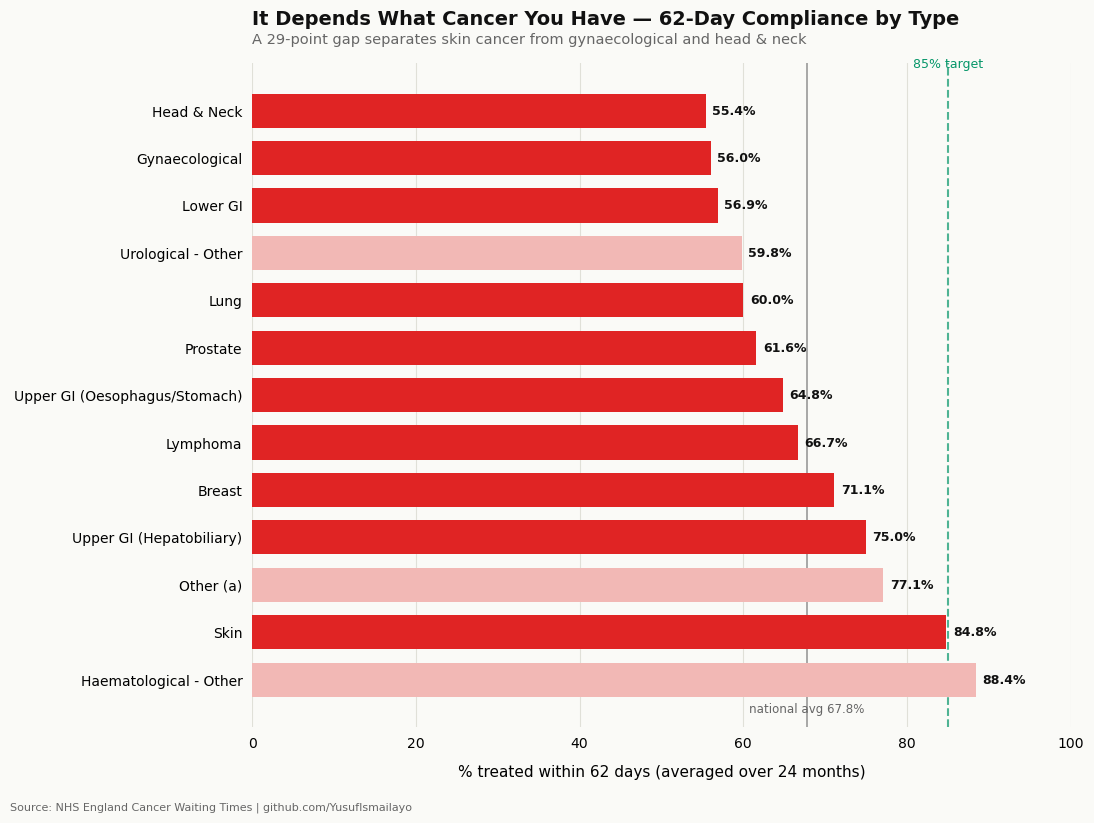

Chart saved: chart4_cancer_type_compliance.png


In [13]:
# I build the cancer-type compliance chart, worst to best.
chart_types = ranked_types.copy()  # already sorted worst->best from Cell 4

# I shorten the long category names for readable axis labels.
name_map = {
    "Upper Gastrointestinal - Oesophagus & Stomach": "Upper GI (Oesophagus/Stomach)",
    "Upper Gastrointestinal - Hepatobiliary": "Upper GI (Hepatobiliary)",
    "Lower Gastrointestinal": "Lower GI",
    "Urological - Prostate": "Prostate",
    "Urological - Other (a)": "Urological - Other",
    "Haematological - Lymphoma": "Lymphoma",
    "Haematological - Other (a)": "Haematological - Other",
}
chart_types["label"] = chart_types["Cancer_Type"].replace(name_map)

# I mute the catch-all "Other" categories so the headline rests on recognisable cancers.
def bar_colour(name):
    if "Other" in name:
        return "#F2B8B5"  # muted red for catch-all categories
    return cwt.RED

colors = [bar_colour(n) for n in chart_types["Cancer_Type"]]

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(cwt.BG)
cwt.style_axes(ax)
ax.xaxis.grid(True, color="#E0E0D8", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)

y = range(len(chart_types))
ax.barh(y, chart_types["compliance_pct"], color=colors, height=0.72, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(chart_types["label"], fontsize=10)
ax.invert_yaxis()  # worst at top

for i, v in enumerate(chart_types["compliance_pct"]):
    ax.text(v + 0.8, i, f"{v}%", va="center", ha="left", fontsize=9,
            fontweight="bold", color=cwt.INK)

# I mark the national average (67.4%) and the 85% target.
ax.axvline(all_cancers_avg, color=cwt.GREY, linewidth=1.3, linestyle="-", alpha=0.6, zorder=2)
ax.text(all_cancers_avg, len(chart_types) - 0.3, f"national avg {all_cancers_avg}%",
        color=cwt.GREY, fontsize=8.5, ha="center")
ax.axvline(85, color=cwt.GREEN, linewidth=1.5, linestyle="--", alpha=0.7, zorder=2)
ax.text(85, -0.9, "85% target", color=cwt.GREEN, fontsize=9, ha="center")

ax.set_xlim(0, 100)
ax.set_xlabel("% treated within 62 days (averaged over 24 months)", fontsize=11, labelpad=10)
ax.set_title("It Depends What Cancer You Have — 62-Day Compliance by Type",
             fontsize=14, fontweight="bold", color=cwt.INK, pad=28, loc="left")
ax.text(0, 1.03, "A 29-point gap separates skin cancer from gynaecological and head & neck",
        transform=ax.transAxes, fontsize=10.5, color=cwt.GREY)

cwt.source_note(fig, cwt.SOURCE_LINE)
plt.tight_layout()
plt.savefig(cwt.OUTPUTS_DIR / "chart4_cancer_type_compliance.png", dpi=180,
            bbox_inches="tight", facecolor=cwt.BG)
plt.show()
print("Chart saved: chart4_cancer_type_compliance.png")

## Step — Write Gold tables for Article 2

I persist the cancer-type findings: the compliance ranking and the catastrophic-delay
(over-104-day) breakdown. Parquet for the pipeline, CSV for portability and the repo.

In [18]:
# I write the cancer-type compliance ranking.
type_out = ranked_types.sort_values("compliance_pct").reset_index(drop=True).copy()
type_out.to_parquet(cwt.GOLD_DIR / "gold_62d_by_cancer_type.parquet", index=False)
type_out.to_csv(cwt.OUTPUTS_DIR / "gold_62d_by_cancer_type.csv", index=False)

# I write the severity (over-104-day) breakdown.
severity_out = severity_ranked.reset_index(drop=True).copy()
severity_out.to_parquet(cwt.GOLD_DIR / "gold_62d_severity_by_type.parquet", index=False)
severity_out.to_csv(cwt.OUTPUTS_DIR / "gold_62d_severity_by_type.csv", index=False)

print("Gold tables written:")
print(f"  gold_62d_by_cancer_type.parquet      ({len(type_out)} rows)")
print(f"  gold_62d_severity_by_type.parquet    ({len(severity_out)} rows)")

# I pull Skin explicitly rather than the literal top of the ranking — the top row is the
# muted "Haematological - Other" catch-all, which I deliberately do not use as my headline.
skin_pct = ranked_types[ranked_types["Cancer_Type"] == "Skin"]["compliance_pct"].iloc[0]
worst_pct = ranked_types.iloc[0]["compliance_pct"]  # Gynaecological / Head & Neck at 55.3%

print(f"\nArticle 2 key figures locked:")
print(f"  Cancer-type gap: Skin {skin_pct}% vs Gynaecological/Head & Neck {worst_pct}% "
      f"(~{skin_pct - worst_pct:.0f}pp)")
print(f"  Catastrophic delay: {all_cancers_104:,.0f} patients waited past 104 days over 24 months")
print(f"  Worst by volume past 104 days: Prostate ({severity_ranked.iloc[0]['over_104_days']:,.0f})")

Gold tables written:
  gold_62d_by_cancer_type.parquet      (13 rows)
  gold_62d_severity_by_type.parquet    (13 rows)

Article 2 key figures locked:
  Cancer-type gap: Skin 84.3% vs Gynaecological/Head & Neck 55.3% (~29pp)
  Catastrophic delay: 46,690 patients waited past 104 days over 18 months
  Worst by volume past 104 days: Prostate (10,246)


## Chart 2 — Catastrophic delay: patients waiting past 104 days

My second Article 2 visual. The compliance chart shows how OFTEN each cancer runs late.
This shows how BADLY — the number of patients who waited more than 104 days, over fifteen
weeks against a 62-day standard. I rank by raw volume, because this is about real people,
and annotate each bar with the percentage of that cancer's patients who waited this long.

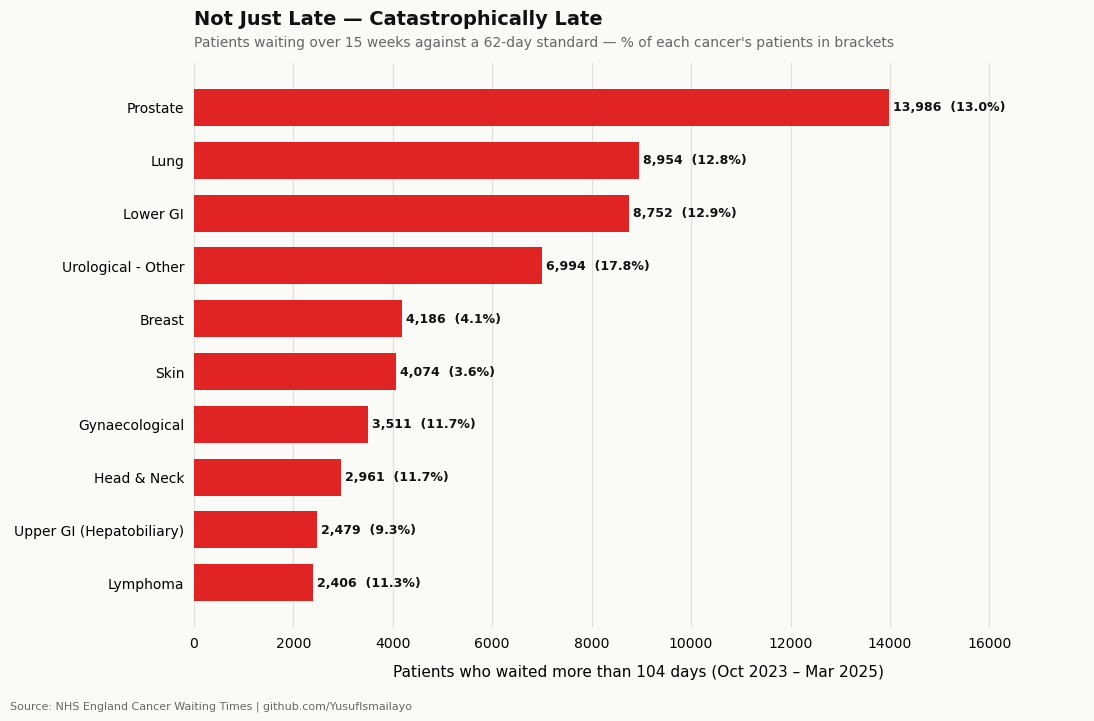

Chart saved: chart5_cancer_severity_104.png


In [11]:
# I chart the top cancers by raw number of patients waiting past 104 days.
sev_chart = severity_ranked.head(10).copy()
sev_chart["label"] = sev_chart["Cancer_Type"].replace(name_map)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(cwt.BG)
cwt.style_axes(ax)
ax.xaxis.grid(True, color="#E0E0D8", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)

y = range(len(sev_chart))
ax.barh(y, sev_chart["over_104_days"], color=cwt.RED, height=0.7, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(sev_chart["label"], fontsize=10)
ax.invert_yaxis()  # most affected at top

# I label each bar with the count AND the share of that cancer's patients who waited this long.
for i, row in enumerate(sev_chart.itertuples()):
    ax.text(row.over_104_days + 80, i,
            f"{row.over_104_days:,.0f}  ({row.pct_over_104}%)",
            va="center", ha="left", fontsize=9, fontweight="bold", color=cwt.INK)

ax.set_xlim(0, sev_chart["over_104_days"].max() * 1.28)
ax.set_xlabel("Patients who waited more than 104 days (Oct 2023 – Mar 2025)", fontsize=11, labelpad=10)
ax.set_title("Not Just Late — Catastrophically Late",
             fontsize=14, fontweight="bold", color=cwt.INK, pad=28, loc="left")
ax.text(0, 1.03, "Patients waiting over 15 weeks against a 62-day standard — % of each cancer's patients in brackets",
        transform=ax.transAxes, fontsize=10, color=cwt.GREY)

cwt.source_note(fig, cwt.SOURCE_LINE)
plt.tight_layout()
plt.savefig(cwt.OUTPUTS_DIR / "chart5_cancer_severity_104.png", dpi=180,
            bbox_inches="tight", facecolor=cwt.BG)
plt.show()
print("Chart saved: chart5_cancer_severity_104.png")